# **INFORMASI DATASET**

Dataset ini menyajikan gambaran mendalam mengenai perilaku transaksi dan pola aktivitas keuangan, sehingga sangat ideal untuk eksplorasi **deteksi penipuan (fraud detection)** dan **identifikasi anomali**. Dataset ini mencakup **2.512 sampel data transaksi**, yang mencakup berbagai atribut transaksi, demografi nasabah, dan pola penggunaan.

Setiap entri memberikan wawasan komprehensif terhadap perilaku transaksi, memungkinkan analisis untuk **keamanan finansial** dan pengembangan model prediktif.

## Fitur Utama

- **`TransactionID`**: Pengidentifikasi unik alfanumerik untuk setiap transaksi.  
- **`AccountID`**: ID unik untuk setiap akun, dapat memiliki banyak transaksi.  
- **`TransactionAmount`**: Nilai transaksi dalam mata uang, mulai dari pengeluaran kecil hingga pembelian besar.  
- **`TransactionDate`**: Tanggal dan waktu transaksi terjadi.  
- **`TransactionType`**: Tipe transaksi berupa `'Credit'` atau `'Debit'`.  
- **`Location`**: Lokasi geografis transaksi (nama kota di Amerika Serikat).  
- **`DeviceID`**: ID perangkat yang digunakan dalam transaksi.  
- **`IP Address`**: Alamat IPv4 yang digunakan saat transaksi, dapat berubah untuk beberapa akun.  
- **`MerchantID`**: ID unik merchant, menunjukkan merchant utama dan anomali transaksi.  
- **`AccountBalance`**: Saldo akun setelah transaksi berlangsung.  
- **`PreviousTransactionDate`**: Tanggal transaksi terakhir pada akun, berguna untuk menghitung frekuensi transaksi.  
- **`Channel`**: Kanal transaksi seperti `Online`, `ATM`, atau `Branch`.  
- **`CustomerAge`**: Usia pemilik akun.  
- **`CustomerOccupation`**: Profesi pengguna seperti `Dokter`, `Insinyur`, `Mahasiswa`, atau `Pensiunan`.  
- **`TransactionDuration`**: Lama waktu transaksi (dalam detik).  
- **`LoginAttempts`**: Jumlah upaya login sebelum transaksi—jumlah tinggi bisa mengindikasikan anomali.

Tugas kamu adalah membuat model clustering yang selanjutnya akan digunakan untuk membuat model klasifikasi.


# **1. Import Library**


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
import joblib

# **2. Memuat Dataset**

In [31]:
url='https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?output=csv'
df = pd.read_csv(url)

In [32]:
df.head()

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 8:06:39


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   PreviousTransactionDate  2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [34]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


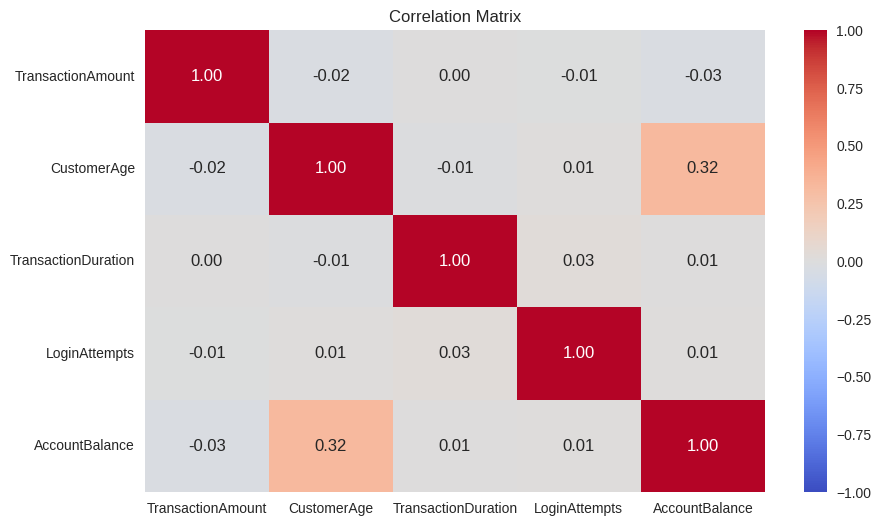

In [35]:
# Menampilkan korelasi antar fitur

# Memilih kolom numerik
numerical_cols = df.select_dtypes(include=['number']).columns

# Menghitung matriks korelasi
correlation = df[numerical_cols].corr()

# Membuat visualisasi heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation,
               annot=True,
               cmap='coolwarm',
               fmt=".2f",
               vmin=-1,
               vmax=1)
plt.title('Correlation Matrix')
plt.show()

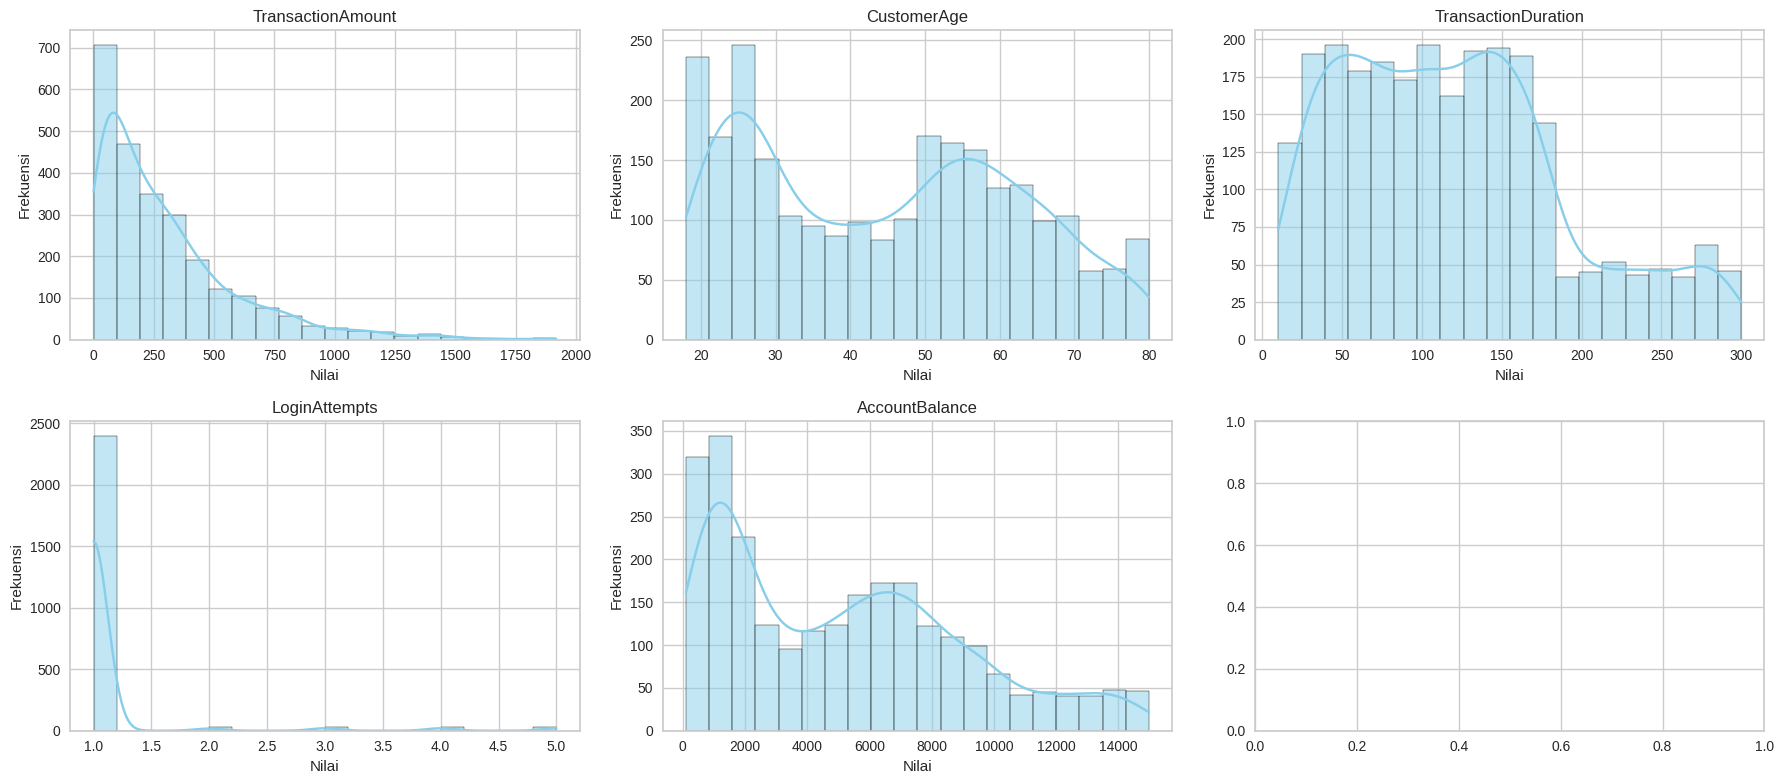

In [36]:
# Menampilkan histogram untuk semua kolom numerik

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, column in enumerate(numerical_cols):

    # Menampilkan histogram dan pastikan plot ditempatkan di subplot (axes) yang benar
    sns.histplot(df[column], bins=20, kde=True, color='skyblue', ax=axes[i])

    # Mengatur judul dan label
    axes[i].set_title(column)
    axes[i].set_xlabel("Nilai")
    axes[i].set_ylabel("Frekuensi")

plt.tight_layout()
plt.show()

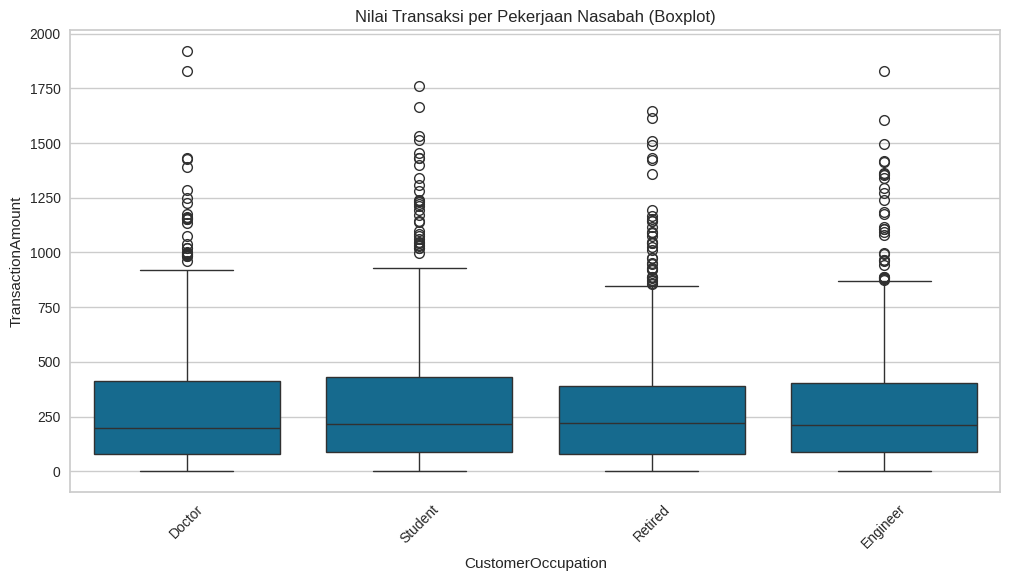

<Axes: xlabel='CustomerOccupation', ylabel='TransactionAmount'>

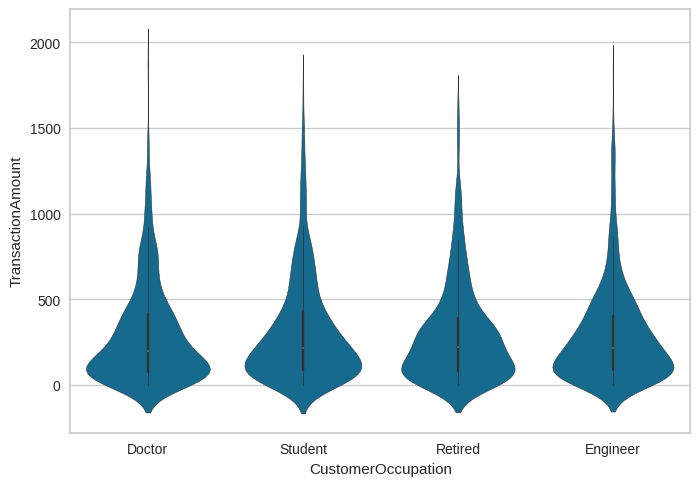

In [37]:
# Visualisasi yang lebih informatif
plt.figure(figsize=(12, 6))

# Membuat visualisasi boxplot untuk melihat sebaran 'TransactionAmount' (y) berdasarkan 'CustomerOccupation' (x)
sns.boxplot(x='CustomerOccupation', y='TransactionAmount', data=df)

plt.title("Nilai Transaksi per Pekerjaan Nasabah (Boxplot)")

# Memutar label sumbu-x agar tidak tumpang tindih
plt.xticks(rotation=45)

plt.show()

sns.violinplot(x='CustomerOccupation', y='TransactionAmount', data=df)

# **3. Pembersihan dan Pra Pemrosesan Data**

In [38]:
# Mengecek dataset menggunakan isnull().sum()
df.isnull().sum()

,0
TransactionID,29
AccountID,21
TransactionAmount,26
PreviousTransactionDate,28
TransactionType,30
Location,30
DeviceID,30
IP Address,20
MerchantID,23
Channel,27


In [39]:
# Mengecek dataset menggunakan duplicated().sum()
df.duplicated().sum()

np.int64(21)

In [40]:
# Menangani data yang hilang.

# Memanggil fungsi untuk menghapus baris yang hilang dan pastikan agar perubahan disimpan kembali ke 'df'
df.dropna(inplace=True)

# Cek kembali dataset menggunakan isnull().sum()
df.isnull().sum()

,0
TransactionID,0
AccountID,0
TransactionAmount,0
PreviousTransactionDate,0
TransactionType,0
Location,0
DeviceID,0
IP Address,0
MerchantID,0
Channel,0


In [41]:
# Menghapus data duplikat.

# Memanggil fungsi untuk menghapus baris duplikat dan pastikan agar perubahan disimpan kembali ke 'df'
df.drop_duplicates(inplace=True)

# Cek kembali dataset menggunakan duplicated().sum()
df.duplicated().sum()

np.int64(0)

In [42]:
# Melakukan drop pada kolom yang memiliki keterangan Date, id, dan IP Address

cols_to_drop = [col for col in df.columns if
                'id' in col.lower() or
                'ip' in col.lower() or
                'date' in col.lower()]

# Menggunakan fungsi .drop() untuk menghapus kolom-kolom yang ada di 'cols_to_drop'.
df = df.drop(columns=cols_to_drop)

# Menampilkan 5 baris pertama untuk memverifikasi
df.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06
5,92.15,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68


In [43]:
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal.

categorical_cols = list(df.select_dtypes(include=['object']).columns)

encoders = {}

for column in categorical_cols:
    label_encoder = LabelEncoder()
    df[column] = label_encoder.fit_transform(df[column])
    encoders[column] = label_encoder

df.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,1,36,0,70.0,0,81.0,1.0,5112.21
1,376.24,1,15,0,68.0,0,141.0,1.0,13758.91
2,126.29,1,23,2,19.0,3,56.0,1.0,1122.35
3,184.50,1,33,2,26.0,3,25.0,1.0,8569.06
5,92.15,1,28,0,18.0,3,172.0,1.0,781.68


In [44]:
# Last checking gunakan columns.tolist() untuk checking seluruh fitur yang ada.

df.columns.tolist()

['TransactionAmount',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance']

In [45]:
# Melakukan Handling Outlier Data menggunakan metode drop.

for col in numerical_cols:

    # Menghitung Kuartil 1 (Q1) dan Kuartil 3 (Q3)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Menghitung Interquartile Range (IQR)
    IQR = Q3 - Q1

    # Menentukan batas bawah (lower bound) dan batas atas (upper bound)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Memfilter DataFrame: Simpan hanya baris di mana nilai 'df[col]' berada DI ANTARA (inklusif) batas bawah dan batas atas.
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Menampilkan statistik deskriptif setelah outlier dihapus
df.describe()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
count,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.0,1945.000000
mean,256.838278,0.771722,21.299743,0.977378,44.693059,1.503342,119.225193,1.0,5100.811913
std,218.370197,0.419830,12.329250,0.804119,17.743453,1.135888,70.600647,0.0,3907.153333
min,0.260000,0.000000,0.000000,0.000000,18.000000,0.000000,10.000000,1.0,102.200000
25%,78.920000,1.000000,11.000000,0.000000,27.000000,0.000000,63.000000,1.0,1488.650000
50%,199.700000,1.000000,21.000000,1.000000,45.000000,1.000000,111.000000,1.0,4693.600000
75%,374.500000,1.000000,32.000000,2.000000,59.000000,3.000000,162.000000,1.0,7659.990000
max,903.190000,1.000000,42.000000,2.000000,80.000000,3.000000,300.000000,1.0,14977.990000


In [46]:
# Melakukan feature scaling menggunakan StandardScaler() untuk fitur numerik.

# Membuat (instantiate) StandardScaler
scaler = StandardScaler()

# Menerapkan (fit) scaler ke data dan sekaligus ubah (transform) data tersebut
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Menampilkan 5 baris pertama untuk memverifikasi hasil scaling
df.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,-1.111922,1,36,0,1.426636,0,-0.541568,0.0,0.002918
1,0.546926,1,15,0,1.313889,0,0.308502,0.0,2.216531
2,-0.597984,1,23,2,-1.448403,3,-0.895763,0.0,-1.018513
3,-0.331350,1,33,2,-1.053790,3,-1.334965,0.0,0.887895
5,-0.754364,1,28,0,-1.504776,3,0.747704,0.0,-1.105726


In [47]:
# Melakukan binning data berdasarkan kondisi rentang nilai pada fitur numerik,

# Menentukan kolom numerik yang ingin Anda kelompokkan
col_to_bin = 'CustomerAge'

# Menentukan nama untuk kolom kategori baru
new_col_name = 'CustomerAgeGroup'

# Menentukan label untuk 3 grup (Anda dapat menentukan nama label-nya sendiri)
# Mulai dari rendah --> sedang --> tinggi
bin_labels = ['Young', 'Adult', 'Senior']

# Menggunakan 'pd.qcut' untuk membagi data menjadi 3 kelompok
df[new_col_name] = pd.qcut(df[col_to_bin], q=3, labels=bin_labels, duplicates='drop')

# Melakukan Label Encoding pada kolom baru ini agar menjadi numerik
label_encoder = LabelEncoder()
df[new_col_name] = label_encoder.fit_transform(df[new_col_name])

# Menyimpan encoder dan tambahkan nama kolom baru ke 'categorical_cols'
encoders[new_col_name] = label_encoder
categorical_cols.extend([new_col_name])

# Menampilkan 5 baris pertama untuk memverifikasi
df.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,CustomerAgeGroup
0,-1.111922,1,36,0,1.426636,0,-0.541568,0.0,0.002918,1
1,0.546926,1,15,0,1.313889,0,0.308502,0.0,2.216531,1
2,-0.597984,1,23,2,-1.448403,3,-0.895763,0.0,-1.018513,2
3,-0.331350,1,33,2,-1.053790,3,-1.334965,0.0,0.887895,2
5,-0.754364,1,28,0,-1.504776,3,0.747704,0.0,-1.105726,2


# **4. Membangun Model Clustering**

In [48]:
# Gunakan describe untuk memastikan proses clustering menggunakan dataset hasil preprocessing

# Membuat salinan (copy) dari 'df' ke variabel 'df_used'
df_used = df.copy()

# Menampilkan ringkasan statistik dari DataFrame 'df'
df_used.describe()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,CustomerAgeGroup
count,1.945000e+03,1945.000000,1945.000000,1945.000000,1.945000e+03,1945.000000,1.945000e+03,1945.0,1.945000e+03,1945.000000
mean,-8.402305e-17,0.771722,21.299743,0.977378,-1.269479e-16,1.503342,2.557223e-17,0.0,-6.027740e-17,1.015424
std,1.000257e+00,0.419830,12.329250,0.804119,1.000257e+00,1.135888,1.000257e+00,0.0,1.000257e+00,0.820123
min,-1.175271e+00,0.000000,0.000000,0.000000,-1.504776e+00,0.000000,-1.547483e+00,0.0,-1.279678e+00,0.000000
25%,-8.149648e-01,1.000000,11.000000,0.000000,-9.974163e-01,0.000000,-7.965883e-01,0.0,-9.247374e-01,0.000000
50%,-2.617251e-01,1.000000,21.000000,1.000000,1.730327e-02,1.000000,-1.165330e-01,0.0,-1.042490e-01,1.000000
75%,5.389562e-01,1.000000,32.000000,2.000000,8.065296e-01,3.000000,6.060257e-01,0.0,6.551666e-01,2.000000
max,2.960651e+00,1.000000,42.000000,2.000000,1.990369e+00,3.000000,2.561185e+00,0.0,2.528623e+00,2.000000


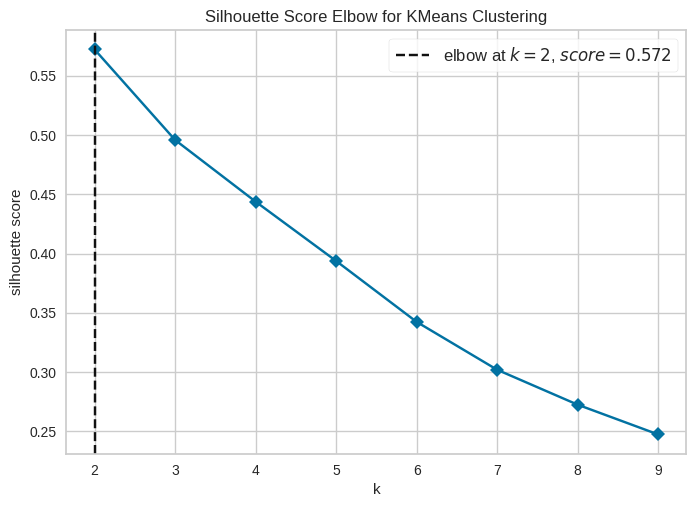

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [49]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()

# Membuat (instantiate) model clustering
model = KMeans()

visualizer = KElbowVisualizer(model,
                       k=(2,10),
                       metric='silhouette',
                       timings=False)

# Menjalankan (fit) visualizer pada data
visualizer.fit(df)

# Menampilkan plot
visualizer.show()

In [50]:
# Menggunakan algoritma K-Means Clustering

# Membuat (instantiate) objek model KMeans
# Menentukan jumlah cluster (n_clusters)
model = KMeans(n_clusters=3, random_state=42)

# Melatih (fit) model dengan data Anda (df)
model.fit(df)

KMeans(n_clusters=3, random_state=42)

In [51]:
# Menyimpan model menggunakan joblib
joblib.dump(model, "model_clustering.h5")

['model_clustering.h5']

In [52]:
# Menghitung dan menampilkan nilai Silhouette Score.


# Mendapatkan hasil (label) cluster dari model 'kmeans' yang telah di-fit
labels = model.labels_

# Memanggil fungsi untuk menghitung silhouette score
score = silhouette_score(df, labels)

# Cetak skornya
print("Silhouette Score:", score)

Silhouette Score: 0.496174599166406


/tmp/ipykernel_4250/3184914951.py:17: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


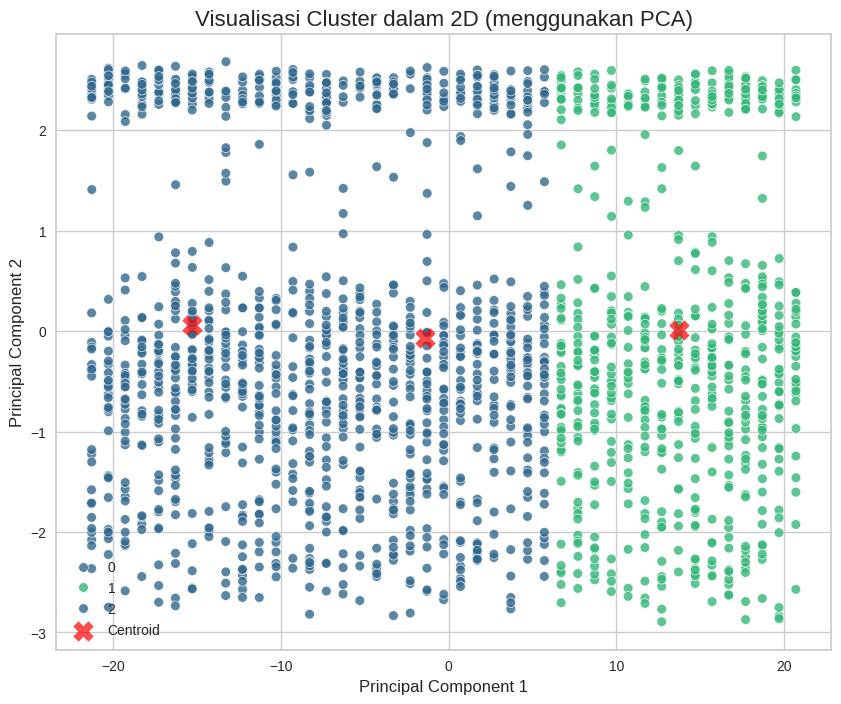

In [53]:
# Membuat visualisasi hasil clustering

# Membuat (instantiate) objek PCA untuk 2 komponen (n_components=2)
pca = PCA(n_components=2)

# Menerapkan (fit) PCA ke data 'df' dan transformasikan data tersebut
df_pca = pca.fit_transform(df)

# Membuat DataFrame baru 'df_pca' dari hasil transformasi
df_pca = pd.DataFrame(data=df_pca, columns=['Principal Component 1', 'Principal Component 2'])

# Menambahkan kolom 'Cluster' ke 'df_pca' menggunakan 'labels'(variabel dari hasil 'kmeans.labels_' sebelumnya)
df_pca['Cluster'] = labels

# Membuat scatter plot menggunakan Seaborn
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Cluster',  # Warnai titik berdasarkan kolom 'Cluster'
    palette=sns.color_palette("viridis", n_colors=2),
    data=df_pca,
    legend="full",
    alpha=0.8
)

plt.title('Visualisasi Cluster dalam 2D (menggunakan PCA)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
centers = pca.transform(model.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.7, marker='X', label='Centroid')
plt.legend()
plt.show()

In [54]:
# Membangun model menggunakan PCA.

# Membuat (instantiate) objek PCA dengan 2 komponen
pca = PCA(n_components=2)

# Menerapkan (fit) PCA ke data 'df_used' dan transformasikan data tersebut
df_pca_array = pca.fit_transform(df_used)

# Membuat DataFrame baru 'data_final' dari hasil array PCA
data_final = pd.DataFrame(data=df_pca_array, columns=['PCA1', 'PCA2'])

# Membuat (instantiate) model KMeans BARU
kmeans_pca = KMeans(n_clusters=3, random_state=42)

# Melatih (fit) model KMeans BARU ini HANYA pada 'data_final'
kmeans_pca.fit(data_final)

KMeans(n_clusters=3, random_state=42)

In [55]:
# Simpan model PCA sebagai perbandingan dengan menjalankan cell code ini joblib.dump(model,"PCA_model_clustering.h5")
joblib.dump(kmeans_pca, "PCA_model_clustering.h5")

['PCA_model_clustering.h5']

# **5. Interpretasi Cluster**

In [56]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik.

# Menambahkan kolom 'Cluster' baru berupa 'labels' (variabel dari 'kmeans.labels_' sebelumnya)
df_used['Cluster'] = labels

# Mengelompokkan (groupby) 'df_used' berdasarkan 'Cluster' dan hitung agregasi untuk 'numerical_cols'.
agg_summary = df_used.groupby('Cluster')[numerical_cols].agg(['mean', 'min', 'max']).round(2).T

# Menampilkan hasil ringkasan
display(agg_summary)

Cluster                      0     1     2
TransactionAmount   mean -0.01  0.01  0.00
                    min  -1.17 -1.18 -1.17
                    max   2.96  2.90  2.90
CustomerAge         mean  0.01 -0.05  0.04
                    min  -1.50 -1.50 -1.50
                    max   1.99  1.99  1.99
TransactionDuration mean  0.01 -0.03  0.02
                    min  -1.55 -1.55 -1.55
                    max   2.56  2.55  2.55
LoginAttempts       mean  0.00  0.00  0.00
                    min   0.00  0.00  0.00
                    max   0.00  0.00  0.00
AccountBalance      mean -0.03  0.00  0.02
                    min  -1.28 -1.28 -1.28
                    max   2.52  2.53  2.52

1. **CLUSTER 0: Nasabah Cenderung Pasif & Saldo Rendah**:
  - **Rata-rata (mean) TransactionAmount:** -0.01
  - **Rata-rata (mean) CustomerAge:** 0.01
  - **Rata-rata (mean) TransactionDuration:** 0.01
  - **Rata-rata (mean) AccountBalance:** -0.03
  - **Analisis:** Cluster ini berisi nasabah dengan aktivitas transaksi yang cenderung sedikit di bawah rata-rata. Nilai transaksi dan saldo yang relatif rendah menunjukkan bahwa kelompok ini memiliki daya beli yang tidak terlalu tinggi. Meskipun durasi transaksi berada di sekitar rata-rata, pola penggunaan layanan terlihat tidak terlalu intens. Nasabah dalam cluster ini kemungkinan hanya menggunakan layanan perbankan untuk kebutuhan dasar dan tidak terlalu aktif dalam melakukan transaksi dalam jumlah besar.

2.   **CLUSTER 1: Nasabah Rata-rata &Stabil**:
  - **Rata-rata (mean) TransactionAmount:** 0.01
  - **Rata-rata (mean) CustomerAge:** -0.05
  - **Rata-rata (mean) TransactionDuration:** -0.03
  - **Rata-rata (mean) AccountBalance:** 0.00
  - **Analisis:** Cluster ini mencerminkan nasabah dengan perilaku yang cukup seimbang di hampir semua aspek. Nilai rata-rata pada setiap fitur berada di sekitar nol, yang berarti kelompok ini merepresentasikan nasabah “umum” atau rata-rata. Aktivitas transaksi, usia, durasi, dan saldo tidak menunjukkan perbedaan signifikan dibanding keseluruhan populasi. Nasabah dalam cluster ini cenderung menggunakan layanan secara normal tanpa kecenderungan ekstrem, baik dalam hal frekuensi maupun nilai transaksi.


3.   **CLUSTER 2: Nasabah Lebih Aktif & Potensial Tinggi**:
- **Rata-rata (mean) TransactionAmount:** 0.00
- **Rata-rata (mean) CustomerAge:** 0.04
- **Rata-rata (mean) TransactionDuration:** 0.02
- **Rata-rata (mean) AccountBalance:** 0.02
- **Analisis:** Cluster ini berisi nasabah yang menunjukkan kecenderungan sedikit lebih aktif dibandingkan kelompok lainnya. Nilai rata-rata yang positif pada durasi transaksi dan saldo menunjukkan bahwa mereka lebih sering berinteraksi dengan layanan dan memiliki kapasitas finansial yang relatif lebih baik. Usia yang sedikit lebih tinggi dari rata-rata juga bisa mengindikasikan tingkat kestabilan finansial yang lebih matang. Secara keseluruhan, kelompok ini memiliki potensi nilai yang lebih tinggi dan dapat menjadi target yang baik untuk penawaran produk premium atau layanan tambahan.

# **6. Mengeksport Data**

In [57]:
df_used.rename(columns={"Cluster": "Target"}, inplace=True)

df_used.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,CustomerAgeGroup,Target
0,-1.111922,1,36,0,1.426636,0,-0.541568,0.0,0.002918,1,1
1,0.546926,1,15,0,1.313889,0,0.308502,0.0,2.216531,1,2
2,-0.597984,1,23,2,-1.448403,3,-0.895763,0.0,-1.018513,2,2
3,-0.331350,1,33,2,-1.053790,3,-1.334965,0.0,0.887895,2,1
5,-0.754364,1,28,0,-1.504776,3,0.747704,0.0,-1.105726,2,1


In [58]:
# Simpan Data
df_used.to_csv('data_clustering.csv', index=False)